# Sesión 5: Detección de Malware en APKs

Instructor:

- Dr. Lázaro Bustio Martínez – IBERO, Ciudad de México, México (lazaro.bustio@ibero.mx)

## Introducción

En el contexto de la seguridad cibernética, la detección de aplicaciones maliciosas (APKs) representa un desafío crítico. Con el crecimiento exponencial de las aplicaciones móviles y su uso generalizado, es fundamental identificar y mitigar las amenazas potenciales que pueden comprometer la seguridad y privacidad de los usuarios. En esta práctica, se introducirá a los participantes en la detección de APKs maliciosas explorando técnicas de Aprendizaje Automático y los conocimientos adquiridos durante el diplomado.

## Objetivo

Aplicar técnicas y algoritmos de Aprendizaje Automatizado y clasificación de datos para la detección de APKs maliciosas.

## Preguntas de Investigación

Siguiendo la metodología de un proyecto de Ciencia de Datos vista en la Sesión 1 (comprensión del negocio, enfoque analítico, preparación de datos, modelado y evaluación), este ejercicio busca responder:

1. ¿Existen permisos de Android que, por sí solos, sean fuertes indicadores de que una aplicación es maliciosa?
2. ¿Es posible distinguir APKs benignas de maliciosas usando únicamente el patrón de permisos que declaran, sin analizar su código ni su comportamiento en ejecución?
3. ¿Qué tan bien generaliza un modelo entrenado con este enfoque a APKs que nunca ha visto antes?

## Hipótesis

- **H1**: Existe un subconjunto reducido de permisos "sensibles" (relacionados con SMS, estado del teléfono, ubicación) cuya presencia está fuertemente asociada con malware.
- **H2**: La separación entre APKs benignas y maliciosas es lo suficientemente marcada como para lograrse incluso con un método no supervisado (agrupamiento), sin usar las etiquetas reales durante el entrenamiento.
- **H3**: Un modelo de clasificación supervisada superará al agrupamiento no supervisado, pero su desempeño en datos genuinamente nuevos (conjunto de prueba) podría ser menor que en el conjunto de validación, dado el tamaño reducido del dataset (398 muestras).

## Desarrollo

Este notebook es autocontenido: las indicaciones, explicaciones y desarrollo de cada paso de la práctica están incluidas en las celdas de texto a lo largo del documento.

### Configuraciones del entorno

Para poder trabajar con Python de una manera más asequible y práctica, se usará Jupyter Notebooks de Google Colaboratory (https://colab.research.google.com). Jupyter Notebooks es una herramienta de código abierto que permite crear documentos interactivos con código en vivo, visualizaciones y texto explicativo, ideal para actividades como análisis de datos, investigación académica y desarrollo de software. Sus ventajas incluyen su interactividad, flexibilidad para trabajar con varios lenguajes de programación, integración de documentación y facilidad para la colaboración en proyectos.

#### Instalación de librerías

Adicionalmente se deben instalar algunas librerías para ser usadas en esta práctica. Las librerías a instalar son:

- **[Pandas](https://pandas.pydata.org/):** La biblioteca pandas es una herramienta de análisis de datos y manipulación de estructuras en Python que proporciona estructuras de datos flexibles, como DataFrames y Series, diseñadas para trabajar eficientemente con datos tabulares y de series temporales. Ofrece funcionalidades para la carga de datos desde múltiples fuentes, limpieza y transformación de datos, indexación avanzada, agregaciones, operaciones estadísticas y generación de visualizaciones. Su capacidad para manejar grandes volúmenes de datos y su amplia gama de funcionalidades la convierten en una opción preferida en entornos de ciencia de datos, análisis financiero y otras áreas que requieren manipulación y análisis de datos.
- **[PyArrow:](https://arrow.apache.org/docs/python/index.html)** Es una biblioteca de Python desarrollada por Apache Arrow, diseñada para mejorar el intercambio de datos entre diferentes procesos y sistemas. Proporciona un conjunto de herramientas y funcionalidades para la manipulación eficiente de datos en memoria y su intercambio entre diferentes entornos, como Python, R, Java, C++, entre otros. PyArrow se destaca por su capacidad para manejar grandes volúmenes de datos de manera eficiente, su soporte para varios formatos de datos, como Feather y Parquet, y su integración con otras bibliotecas populares de análisis de datos, como pandas y NumPy. En resumen, PyArrow es una herramienta fundamental para mejorar el rendimiento y la interoperabilidad en aplicaciones que involucran el análisis y procesamiento de datos a gran escala.
- **[Scikit-Learn:](https://scikit-learn.org/stable/)** Scikit-learn es una biblioteca de aprendizaje automático de código abierto para Python que ofrece una amplia gama de algoritmos y herramientas para la implementación eficiente de modelos de aprendizaje supervisado y no supervisado. Con una API bien diseñada y optimizada para el rendimiento, scikit-learn permite a los desarrolladores experimentar con algoritmos de aprendizaje automático de manera fácil y eficiente. Su integración con otras bibliotecas de Python como NumPy y Pandas facilita el análisis de datos complejos, mientras que su documentación completa y detallada proporciona recursos exhaustivos para usuarios de todos los niveles de experiencia. En resumen, scikit-learn es una herramienta esencial para aquellos que buscan construir modelos de aprendizaje automático robustos y escalables en Python.
- **[Matplotlib:](https://matplotlib.org/)** Matplotlib es una biblioteca de visualización de datos en Python que permite crear gráficos estáticos, animados e interactivos. Es una herramienta muy versátil y ampliamente utilizada en el ámbito de la ciencia de datos, la ingeniería y la investigación académica para generar gráficos de alta calidad. Matplotlib proporciona una amplia variedad de funciones para crear gráficos de líneas, dispersión, barras, histogramas, gráficos de contorno, entre otros tipos de visualizaciones. Además, ofrece la capacidad de personalizar prácticamente todos los aspectos de un gráfico, desde el color y el estilo de línea hasta los ejes y etiquetas.
- **[Seaborn:](https://seaborn.pydata.org/)** Seaborn es una biblioteca de visualización de datos en Python que se basa en Matplotlib y ofrece una interfaz de alto nivel para crear gráficos estadísticos atractivos y informativos. Con una sintaxis simplificada, Seaborn permite trabajar de manera intuitiva con estructuras de datos de pandas y ofrece una amplia gama de tipos de gráficos, como gráficos de dispersión, histogramas, gráficos de barras y más. Además, proporciona herramientas para personalizar fácilmente el aspecto visual de los gráficos, lo que la convierte en una opción popular para la exploración de datos y el análisis estadístico en Python.

In [1]:
# El comando "%pip install xxxx" se ejecuta en un entorno de Jupyter Notebook y se
# utiliza para instalar una biblioteca xxxx en ese entorno específico.
%pip install pandas
%pip install pyarrow
%pip install scikit-learn
%pip install matplotlib
%pip install seaborn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


#### Uso de librerías

In [2]:
# Importaciones de librerías de manipulación de datos
import pandas as pd
import numpy as np

# Importaciones de librerías de visualización
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

# Importaciones del módulo warnings para manejar advertencias
import warnings
# Desactiva todas las advertencias
warnings.filterwarnings("ignore")

# Importaciones de librerías para el Aprendizaje Automatizado
from sklearn.metrics import (
    confusion_matrix, classification_report,
    precision_score, recall_score, f1_score, roc_auc_score,
    silhouette_score
)
from sklearn.model_selection import train_test_split, cross_validate, StratifiedKFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.calibration import CalibratedClassifierCV
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.base import clone
import joblib

### Adquisición de datos

Analiza el documento “Android manifest file permissions.pdf” para conocer los permisos que Android pone a disposición de los desarrolladores. También revisar el documento “A Comprehensive Analysis of the Android Permissions System.pdf” para entender la arquitectura de permisos del sistema Android.

El dataset `apk_train.csv`, incluido en esta carpeta, contiene muestras de APKs maliciosas y APKs benignas. Este dataset está compuesto por 398 muestras de APKs, de las cuales 199 son maliciosas (``type=1``) y 199 benignas (``type=0``). Cada una de estas muestras se representa mediante cada uno de los permisos que Android pone a disposición de los desarrolladores. Cada una de las muestras de APK, si requiere de un permiso, se marca con ``1`` la celda correspondiente; y ``0`` en caso contrario.

In [3]:
# Ubicación de los datos. En caso de ser otra ubicación diferente,
# debe actualizarse aquí.
data_path = 'apk_train.csv'

apks_df = pd.read_csv(data_path, sep=';')
apks_df.shape

(398, 331)

### Análisis Exploratorio de Datos

Antes de cualquier análisis, se hace un primer vistazo a los datos: se revisa su forma, sus tipos de dato y si existen valores faltantes. Este paso es básico pero fundamental antes de continuar con cualquier análisis.

In [4]:
# Primer vistazo a los datos
print('Primeras filas:')
display(apks_df.head())

print('Tipos de dato presentes:')
print(apks_df.dtypes.value_counts())

print('Valores faltantes (total en todo el dataset):')
print(apks_df.isna().sum().sum())

Primeras filas:


,android,android.app.cts.permission.TEST_GRANTED,android.intent.category.MASTER_CLEAR.permission.C2D_MESSAGE,android.os.cts.permission.TEST_GRANTED,android.permission.ACCESS_ALL_DOWNLOADS,android.permission.ACCESS_ALL_EXTERNAL_STORAGE,android.permission.ACCESS_BLUETOOTH_SHARE,android.permission.ACCESS_CACHE_FILESYSTEM,android.permission.ACCESS_CHECKIN_PROPERTIES,android.permission.ACCESS_COARSE_LOCATION,...,com.android.voicemail.permission.WRITE_VOICEMAIL,com.foo.mypermission,com.foo.mypermission2,org.chromium.chrome.shell.permission.C2D_MESSAGE,org.chromium.chrome.shell.permission.DEBUG,org.chromium.chrome.shell.permission.SANDBOX,org.chromium.chromecast.shell.permission.SANDBOX,org.chromium.content_shell.permission.SANDBOX,test_permission,type
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1


Tipos de dato presentes:
int64    331
Name: count, dtype: int64
Valores faltantes (total en todo el dataset):
0


Para comenzar el análisis exploratorio de datos (EDA), se debe codificar las etiquetas ``0`` y ``1`` de la columna ``type`` como ``benigno`` y ``maligno`` respectivamente en una nueva columna llamada ``class``.

In [5]:
# Mapear los valores de la columna "type" a las etiquetas "benigno" y "maligno"
apks_df['class'] = apks_df['type'].map({0: 'benigno', 1: 'maligno'})
apks_df

,android,android.app.cts.permission.TEST_GRANTED,android.intent.category.MASTER_CLEAR.permission.C2D_MESSAGE,android.os.cts.permission.TEST_GRANTED,android.permission.ACCESS_ALL_DOWNLOADS,android.permission.ACCESS_ALL_EXTERNAL_STORAGE,android.permission.ACCESS_BLUETOOTH_SHARE,android.permission.ACCESS_CACHE_FILESYSTEM,android.permission.ACCESS_CHECKIN_PROPERTIES,android.permission.ACCESS_COARSE_LOCATION,...,com.foo.mypermission,com.foo.mypermission2,org.chromium.chrome.shell.permission.C2D_MESSAGE,org.chromium.chrome.shell.permission.DEBUG,org.chromium.chrome.shell.permission.SANDBOX,org.chromium.chromecast.shell.permission.SANDBOX,org.chromium.content_shell.permission.SANDBOX,test_permission,type,class
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,maligno
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,maligno
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,maligno
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,maligno
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,maligno
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
393,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,benigno
394,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,benigno
395,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,benigno
396,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,benigno


Una vez cargados los datos se debe analizar el balance de clases para entender la distribución de muestras.

In [6]:
# Contar el número de instancias por clase
class_counts = apks_df['class'].value_counts()

# Mostrar el balance de instancias por clase
print("Balance de instancias por clase:")
print(class_counts)

Balance de instancias por clase:
class
maligno    199
benigno    199
Name: count, dtype: int64


El análisis anterior se ve mejor mediante un gráfico de barras.

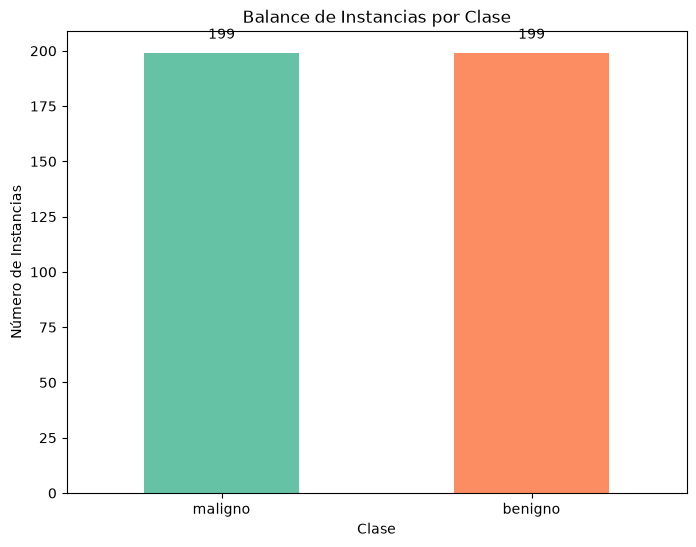

In [7]:
# Definir colores suaves
colors = ['#66c2a5', '#fc8d62']

# Crear un gráfico de barras para mostrar el balance de instancias por clase
plt.figure(figsize=(8, 6))
bars = class_counts.plot(kind='bar', color=colors)
plt.title('Balance de Instancias por Clase')
plt.xlabel('Clase')
plt.ylabel('Número de Instancias')
plt.xticks(rotation=0)

# Agregar el número de instancias en cada barra
for i, v in enumerate(class_counts):
    plt.text(i, v + 5, str(v), ha='center', va='bottom')

plt.show()

Este problema es balanceado. Esto quiere decir que el conjunto de datos contiene una distribución relativamente equitativa de muestras entre las clases objetivo. En el contexto de clasificación de APKs como maliciosas o benignas, un conjunto de datos balanceado implica que hay una cantidad similar de muestras de APK maliciosas y benignas disponibles para el entrenamiento y la evaluación del modelo.

Un conjunto de datos balanceado es crucial para el desarrollo de modelos de aprendizaje automático, ya que ayuda a evitar sesgos y garantiza que el modelo pueda aprender de manera efectiva las características distintivas de cada clase. En este caso, al tener una distribución equilibrada de clases, el modelo no se inclinará hacia ninguna clase en particular y podrá aprender de manera equitativa las características tanto de las APKs maliciosas como de las benignas. Esto puede conducir a un mejor rendimiento del modelo en la clasificación de nuevas muestras no vistas.

A partir de los datos, se explora la distribución de permisos para determinar cuáles son las APKs que requieren el menor y el mayor número de permisos. Además, se busca determinar el promedio de permisos requeridos tanto por las aplicaciones de cada clase como en general.

Se analiza la distribución de permisos para identificar la APK que requiere el menor número de permisos, así como aquella que requiere el mayor número de permisos. También se calcula el promedio de permisos que las aplicaciones de cada clase (maliciosas y benignas) requieren, así como el promedio general de permisos para todas las aplicaciones en el conjunto de datos.

In [8]:
# Calcular el número total de permisos para cada APK
apks_df['total_permisos'] = apks_df.drop(['type', 'class'], axis=1).sum(axis=1)

# Encontrar la APK con el menor y el mayor número de permisos
min_apk = apks_df.loc[apks_df['total_permisos'].idxmin()]
max_apk = apks_df.loc[apks_df['total_permisos'].idxmax()]

print("APK con menos permisos:")
print("Número total de permisos:", min_apk['total_permisos'])
print("\nAPK con más permisos:")
print("Número total de permisos:", max_apk['total_permisos'])

# Calcular el promedio del número de permisos para las aplicaciones de cada clase
promedio_por_clase = apks_df.groupby('class')['total_permisos'].mean()

print("\nPromedio de permisos por clase:")
print(promedio_por_clase)


APK con menos permisos:
Número total de permisos: 0

APK con más permisos:
Número total de permisos: 31

Promedio de permisos por clase:
class
benigno     3.301508
maligno    12.206030
Name: total_permisos, dtype: float64


El promedio de permisos por clase da un primer indicio, pero no dice nada sobre la forma de la distribución ni sobre posibles valores atípicos. Se visualiza la distribución completa con un histograma y un boxplot separado por clase.

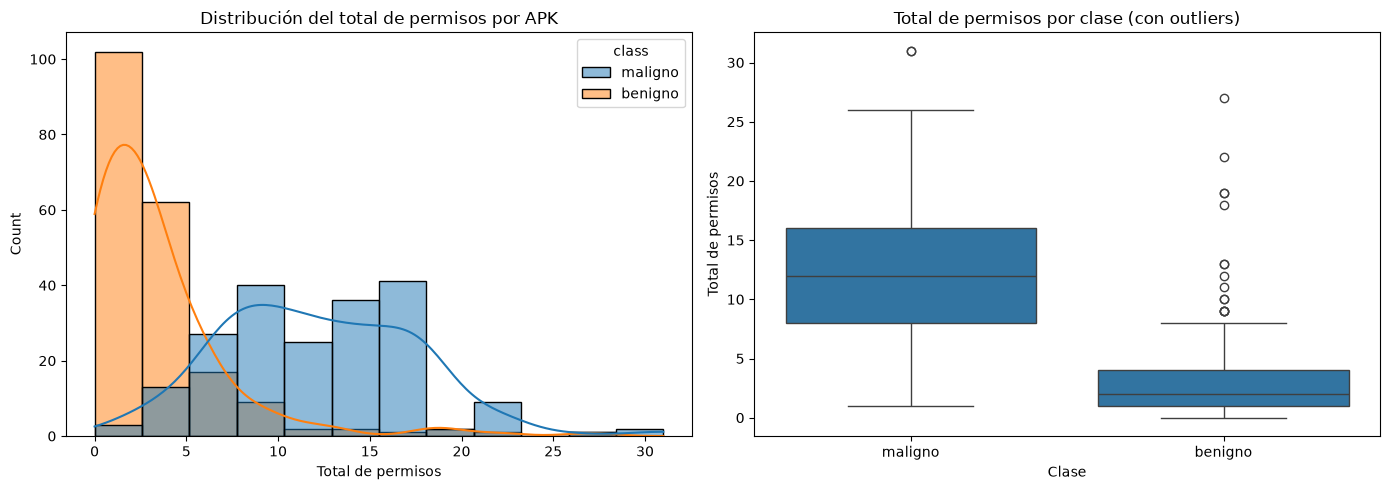

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histograma de la cantidad total de permisos por APK
sns.histplot(data=apks_df, x='total_permisos', hue='class', kde=True, ax=axes[0])
axes[0].set_title('Distribución del total de permisos por APK')
axes[0].set_xlabel('Total de permisos')

# Boxplot por clase para comparar distribuciones y detectar outliers
sns.boxplot(data=apks_df, x='class', y='total_permisos', ax=axes[1])
axes[1].set_title('Total de permisos por clase (con outliers)')
axes[1].set_xlabel('Clase')
axes[1].set_ylabel('Total de permisos')

plt.tight_layout()
plt.show()

Las APKs maliciosas suelen solicitar más permisos en promedio, pero el boxplot también deja ver casos atípicos en ambas clases: APKs benignas que piden muchos permisos, y APKs maliciosas muy discretas en la cantidad de permisos que solicitan. Esto confirma que el número total de permisos por sí solo no basta para distinguir malware de apps benignas — de ahí que el análisis por permiso individual (sección anterior) y el modelo de clasificación (más adelante) sean necesarios.

### Permisos más asociados a malware

Antes de pasar al agrupamiento y la clasificación, conviene preguntarse: ¿qué permisos delatan más a una APK maliciosa? Esto no solo aporta contexto de seguridad (ver los documentos sobre permisos de Android en la carpeta `Bibliografía`), sino que ayuda a entender más adelante por qué los clasificadores logran separar tan bien ambas clases.

Top 10 permisos más asociados a MALWARE:
android.permission.READ_PHONE_STATE          0.834171
android.permission.READ_SMS                  0.603015
android.permission.ACCESS_WIFI_STATE         0.532663
android.permission.ACCESS_NETWORK_STATE      0.527638
android.permission.WRITE_SMS                 0.517588
android.permission.INTERNET                  0.457286
android.permission.RECEIVE_BOOT_COMPLETED    0.361809
android.permission.ACCESS_COARSE_LOCATION    0.336683
android.permission.SEND_SMS                  0.336683
android.permission.CHANGE_WIFI_STATE         0.311558
dtype: float64


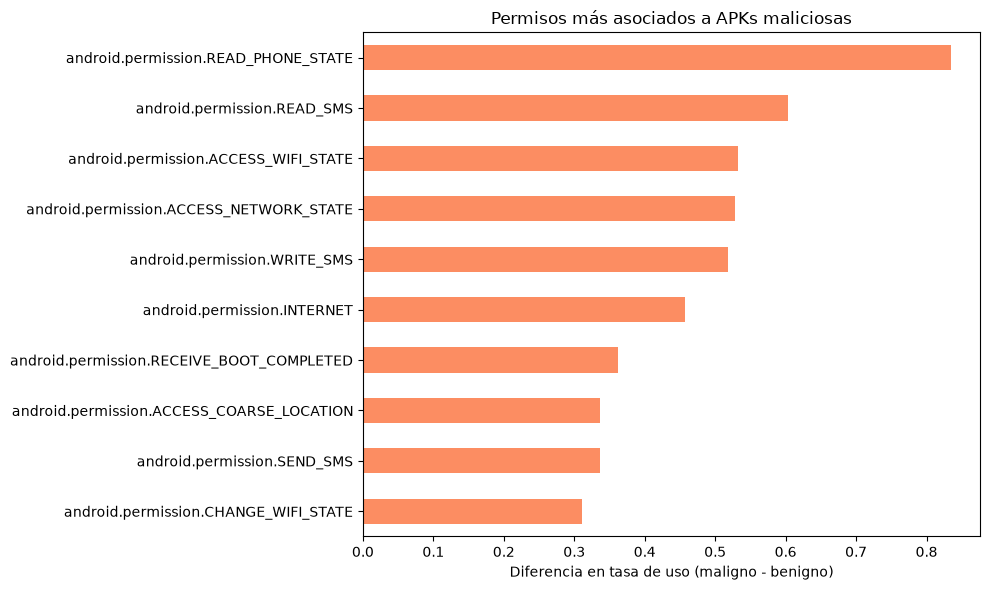

In [10]:
# Para cada permiso, calcular qué tan frecuente es en cada clase y
# ordenar de mayor a menor la diferencia (maligno - benigno).
# Un valor alto indica un permiso mucho más común en malware que en apps benignas.
permisos = [c for c in apks_df.columns if c not in ('type', 'class', 'total_permisos', 'clusters')]
tasa_por_clase = apks_df.groupby('class')[permisos].mean()
diferencia = (tasa_por_clase.loc['maligno'] - tasa_por_clase.loc['benigno']).sort_values(ascending=False)

print('Top 10 permisos más asociados a MALWARE:')
print(diferencia.head(10))

# Visualizar los 10 permisos más discriminantes
plt.figure(figsize=(10, 6))
diferencia.head(10).plot(kind='barh', color='#fc8d62')
plt.xlabel('Diferencia en tasa de uso (maligno - benigno)')
plt.title('Permisos más asociados a APKs maliciosas')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

El gráfico de barras anterior compara los permisos entre sí, pero no muestra de un vistazo qué tan separadas quedan ambas clases para cada uno. Un **diagrama de radar** (visto en la Sesión 4) permite comparar, para los 5 permisos más discriminantes, qué porcentaje de APKs de cada clase los solicita — todo en una sola figura.

In [11]:
%pip install plotly

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [12]:
import plotly.graph_objects as go

# Tomar los 5 permisos más discriminantes ya calculados
top5_permisos = diferencia.head(5).index.tolist()
categorias = [p.split('.')[-1] for p in top5_permisos]  # nombres cortos para el gráfico

# Porcentaje de APKs de cada clase que solicitan cada uno de esos permisos
porcentaje_maligno = (tasa_por_clase.loc['maligno', top5_permisos] * 100).tolist()
porcentaje_benigno = (tasa_por_clase.loc['benigno', top5_permisos] * 100).tolist()

fig = go.Figure()
fig.add_trace(go.Scatterpolar(r=porcentaje_maligno, theta=categorias, fill='toself', name='Maligno'))
fig.add_trace(go.Scatterpolar(r=porcentaje_benigno, theta=categorias, fill='toself', name='Benigno'))
fig.update_layout(
    polar=dict(radialaxis=dict(visible=True, range=[0, 100])),
    title='Top 5 permisos más discriminantes: % de APKs que los solicitan por clase',
    showlegend=True
)
fig.show()

El diagrama de radar deja ver claramente que, para los 5 permisos más discriminantes, el área que cubre la clase "maligno" es mucho mayor que la de "benigno" — confirmando visualmente lo que ya se había encontrado numéricamente.

En vez de ver permiso por permiso, también se pueden agrupar por categoría temática usando `filter()` sobre los nombres de columna. Por ejemplo, los permisos relacionados con **SMS** son un grupo clásico de interés en la detección de malware (los troyanos de SMS son uno de los tipos más comunes de malware en Android, como se describe en la bibliografía del curso).

In [13]:
# Seleccionar todas las columnas de permisos relacionados con SMS
columnas_sms = apks_df.filter(like='SMS').columns.tolist()
print('Permisos relacionados con SMS:', columnas_sms)

# Comparar la tasa de uso de estos permisos entre clases
apks_df.groupby('class')[columnas_sms].mean()

Permisos relacionados con SMS: ['android.permission.BROADCAST_SMS', 'android.permission.CARRIER_FILTER_SMS', 'android.permission.READ_SMS', 'android.permission.RECEIVE_SMS', 'android.permission.SEND_SMS', 'android.permission.WRITE_SMS']


,android.permission.BROADCAST_SMS,android.permission.CARRIER_FILTER_SMS,android.permission.READ_SMS,android.permission.RECEIVE_SMS,android.permission.SEND_SMS,android.permission.WRITE_SMS
class,,,,,,
benigno,0.0,0.0,0.020101,0.025126,0.015075,0.005025
maligno,0.0,0.0,0.623116,0.326633,0.351759,0.522613


Finalmente, se usa `query()` para verificar puntualmente qué tan buena señal es el permiso más discriminante encontrado arriba: de las APKs que lo solicitan, ¿qué proporción son realmente malware?

In [14]:
# Filtrar las APKs que solicitan el permiso más discriminante y revisar su clase real
# (el nombre de la columna se encierra en comillas invertidas porque contiene puntos)
permiso_top = diferencia.index[0]
apks_con_permiso_top = apks_df.query(f"`{permiso_top}` == 1")

print(f'Permiso más discriminante: {permiso_top}')
print(f'Total de APKs que lo solicitan: {len(apks_con_permiso_top)}')
print(apks_con_permiso_top['class'].value_counts(normalize=True))

Permiso más discriminante: android.permission.READ_PHONE_STATE
Total de APKs que lo solicitan: 214
class
maligno    0.88785
benigno    0.11215
Name: proportion, dtype: float64


### Análisis de agrupamiento de datos

A partir de los datos anteriores surge la premisa de que las APKs benignas se deberían agrupar y diferenciarse de las malignas. Aunque inicialmente se puede considerar que en los datos existen 2 grupos bien definidos, esto se debe comprobar. Para ello, se usa el método del codo y el método de la silueta.

In [15]:
# Eliminar las columnas "type" y "class"
X = apks_df.drop(['type', 'class', 'total_permisos'], axis=1)

# Calcular la inercia para diferentes valores de k
inertia = []
silhouette_scores = []
k_values = range(2, 11)  # Probamos con 2 a 10 grupos

for k in k_values:
    print(f'Procesando con k={k}...')
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X)
    inertia.append(kmeans.inertia_)
    silhouette = silhouette_score(X, kmeans.labels_)
    silhouette_scores.append(silhouette)
    print(f'  Inercia para k={k}: {kmeans.inertia_:.2f}')
    print(f'  Puntuación de silueta para k={k}: {silhouette:.2f}')

Procesando con k=2...


  Inercia para k=2: 1666.21
  Puntuación de silueta para k=2: 0.24
Procesando con k=3...
  Inercia para k=3: 1391.59
  Puntuación de silueta para k=3: 0.28
Procesando con k=4...
  Inercia para k=4: 1312.74
  Puntuación de silueta para k=4: 0.23
Procesando con k=5...
  Inercia para k=5: 1193.29
  Puntuación de silueta para k=5: 0.23
Procesando con k=6...
  Inercia para k=6: 1103.71
  Puntuación de silueta para k=6: 0.25
Procesando con k=7...
  Inercia para k=7: 1027.59
  Puntuación de silueta para k=7: 0.26
Procesando con k=8...
  Inercia para k=8: 996.26
  Puntuación de silueta para k=8: 0.25
Procesando con k=9...
  Inercia para k=9: 944.90
  Puntuación de silueta para k=9: 0.26
Procesando con k=10...
  Inercia para k=10: 883.03
  Puntuación de silueta para k=10: 0.27


A partir del coeficiente ``silhouette`` y ``inertia`` se puede determinar el número óptimo de grupos:

In [16]:
# Encontrar el número óptimo de grupos usando el método del codo:
# se calcula cuánto cae la inercia entre cada k y el siguiente, y se busca el
# punto de mayor "curvatura" (donde la caída en la mejora marginal es más
# grande), que es el criterio estándar del método del codo.
delta_inertia = [inertia[i - 1] - inertia[i] for i in range(1, len(inertia))]
curvatura = [delta_inertia[i - 1] - delta_inertia[i] for i in range(1, len(delta_inertia))]
optimal_k_codo = k_values[curvatura.index(max(curvatura)) + 1]

# Encontrar el número óptimo de grupos usando el método de la silueta
optimal_k_silueta = k_values[silhouette_scores.index(max(silhouette_scores))]

print(f"Número óptimo de grupos (método del codo): {optimal_k_codo}")
print(f"Número óptimo de grupos (método de la silueta): {optimal_k_silueta}")

Número óptimo de grupos (método del codo): 3
Número óptimo de grupos (método de la silueta): 3


Lo anterior se puede representar gráficamente para un mejor entendimiento.

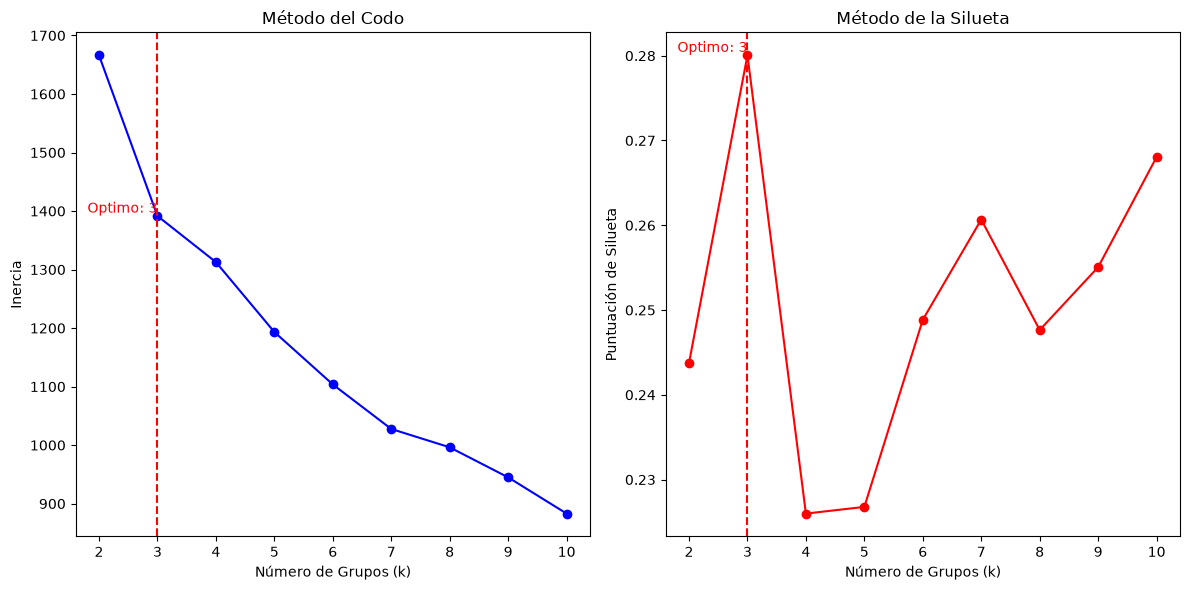

In [17]:
# Configurar el tamaño de la figura
plt.figure(figsize=(12, 6))

# Gráfico del Método del Codo
plt.subplot(1, 2, 1)
plt.plot(k_values, inertia, 'bo-')
plt.axvline(x=optimal_k_codo, color='red', linestyle='--')
plt.text(optimal_k_codo, inertia[k_values.index(optimal_k_codo)], f'Optimo: {optimal_k_codo}', color='red', ha='right', va='bottom')
plt.title('Método del Codo')
plt.xlabel('Número de Grupos (k)')
plt.ylabel('Inercia')
plt.xticks(k_values)

# Gráfico del Método de la Silueta
plt.subplot(1, 2, 2)
plt.plot(k_values, silhouette_scores, 'ro-')
plt.axvline(x=optimal_k_silueta, color='red', linestyle='--')
plt.text(optimal_k_silueta, silhouette_scores[k_values.index(optimal_k_silueta)], f'Optimo: {optimal_k_silueta}', color='red', ha='right', va='bottom')
plt.title('Método de la Silueta')
plt.xlabel('Número de Grupos (k)')
plt.ylabel('Puntuación de Silueta')
plt.xticks(k_values)

plt.tight_layout()
plt.show()


Cuando los métodos del codo y de la silueta arrojan números óptimos diferentes, puede ser un desafío decidir cuál usar. Aquí hay algunas consideraciones que podrían ayudarte a tomar una decisión:

1. **Entender la naturaleza de los datos**: Analiza la naturaleza de tus datos y el contexto del problema. ¿Tiene sentido tener un número específico de grupos dados los conocimientos del dominio?

2. **Evaluar la consistencia de los resultados**: Revisa si los resultados de ambos métodos son consistentes con otras métricas de evaluación o conocimientos previos del dominio.

3. **Explorar diferentes soluciones**: Considera explorar soluciones para ambos números óptimos de grupos y evaluar cómo afectan al resultado final. Puedes analizar la interpretabilidad y coherencia de los grupos resultantes en cada caso.

4. **Prueba cruzada y validación**: Utiliza técnicas de validación cruzada o dividir tus datos en conjuntos de entrenamiento y prueba para evaluar cómo se generaliza cada número óptimo de grupos.

5. **Análisis de sensibilidad**: Realiza un análisis de sensibilidad para evaluar cómo varían los resultados con diferentes números de grupos y cómo eso afecta tus conclusiones finales.

En última instancia, no hay una respuesta definitiva sobre cuál número de grupos es el "correcto". Dependerá del contexto específico del problema y puede requerir un análisis más detallado y juicio experto para tomar una decisión informada.

En cualquier caso se puede experimentar con varios números de grupos y analizar los resultados obtenidos.

**¿Por qué se usa `optimal_k = 2` en vez de 3 (lo que sugieren tanto el codo como la silueta)?** Porque en este ejercicio ya se conoce, por el conocimiento del dominio, que las APKs pertenecen a exactamente 2 categorías reales (benigna/maliciosa) — el objetivo del agrupamiento aquí no es descubrir cuántos grupos naturales hay (para eso sí se seguirían el codo o la silueta a ciegas), sino comprobar si esos 2 grupos reales son recuperables a partir únicamente del patrón de permisos, sin usar las etiquetas. Por eso se fuerza `k=2` deliberadamente, en vez de dejar que el codo o la silueta decidan el número de grupos.

In [18]:
# Establecer el número óptimo de grupos
optimal_k = 2

# Creamos el modelo KMeans con el número óptimo de grupos
kmeans = KMeans(n_clusters=optimal_k, random_state=42)

# Ajustamos el modelo a los datos
kmeans.fit(X)

# Obtenemos las etiquetas de los grupos para cada muestra
labels = kmeans.labels_

# Obtener los centroides de los grupos
centroids = kmeans.cluster_centers_

# Agregar las etiquetas de los grupos al DataFrame
apks_df['clusters'] = labels

# Mostrar las primeras filas del DataFrame con la nueva columna
print(apks_df[["type", "class", "total_permisos", "clusters"]])

     type    class  total_permisos  clusters
0       1  maligno              17         0
1       1  maligno              11         0
2       1  maligno              17         0
3       1  maligno              18         0
4       1  maligno               1         1
..    ...      ...             ...       ...
393     0  benigno               4         1
394     0  benigno               3         1
395     0  benigno               0         1
396     0  benigno               9         1
397     0  benigno               0         1

[398 rows x 4 columns]


**Nota sobre las etiquetas de los clusters:** KMeans es un algoritmo no supervisado, por lo que las etiquetas que asigna a cada cluster (`0`, `1`, ...) son arbitrarias — no sabe cuál cluster corresponde a "benigno" y cuál a "maligno". Antes de poder comparar los clusters contra las clases reales con una matriz de confusión, es necesario alinear cada cluster con la clase real mayoritaria de sus miembros.

In [19]:
# Alinear las etiquetas de los clusters con las clases reales
# (cada cluster se etiqueta con la clase real mayoritaria entre sus miembros)
cluster_to_class = {}
for cluster_id in np.unique(labels):
    mask = labels == cluster_id
    cluster_to_class[cluster_id] = apks_df.loc[mask, 'type'].mode()[0]

labels = np.array([cluster_to_class[c] for c in labels])
apks_df['clusters'] = labels

print("Correspondencia cluster -> clase real mayoritaria:", cluster_to_class)

Correspondencia cluster -> clase real mayoritaria: {np.int32(0): np.int64(1), np.int32(1): np.int64(0)}


Para representar graficamente los grupos obtenidos se debe reducir la dimensionalidad de los datos. Esto se logra mediante el uso del algoritmo [PCA](https://es.wikipedia.org/wiki/An%C3%A1lisis_de_componentes_principales) .

In [20]:
# Obtener la clase de cada muestra de apks_df
clase = apks_df['class'].values

# Crear un DataFrame con la clase
df_clase = pd.DataFrame(clase, columns=['Clase'])

# Obtener el grupo asignado por el algoritmo de agrupamiento
grupo_asignado = pd.DataFrame(labels, columns=['Grupo'])

# Reducir la dimensionalidad de los datos a 2 dimensiones usando PCA
pca = PCA(n_components=2)
X_2d = pca.fit_transform(X)

# Crear un DataFrame con los datos transformados en dos dimensiones
df_2d = pd.DataFrame(X_2d, columns=['Componente Principal 1', 'Componente Principal 2'])

# Concatenar los DataFrames df_2d, df_clase y grupo_asignado
df_resultado = pd.concat([df_2d, df_clase, grupo_asignado], axis=1)

# Convertir la columna 'Grupo' a tipo entero
df_resultado['Grupo'] = df_resultado['Grupo'].astype(int)

# Mostrar el DataFrame resultante
print(df_resultado)

     Componente Principal 1  Componente Principal 2    Clase  Grupo
0                  2.369729               -0.986827  maligno      1
1                  0.861690               -0.577239  maligno      1
2                  2.392812               -1.918197  maligno      1
3                  2.639566               -1.651915  maligno      1
4                 -1.144931               -0.437639  maligno      0
..                      ...                     ...      ...    ...
393               -0.748584               -0.196401  benigno      0
394               -0.783481                0.096902  benigno      0
395               -1.355210               -0.592046  benigno      0
396               -0.760541                0.095255  benigno      0
397               -1.355210               -0.592046  benigno      0

[398 rows x 4 columns]


Una vez reducida la dimensionalidad de los datos, entonces se pueden representar graficamente.

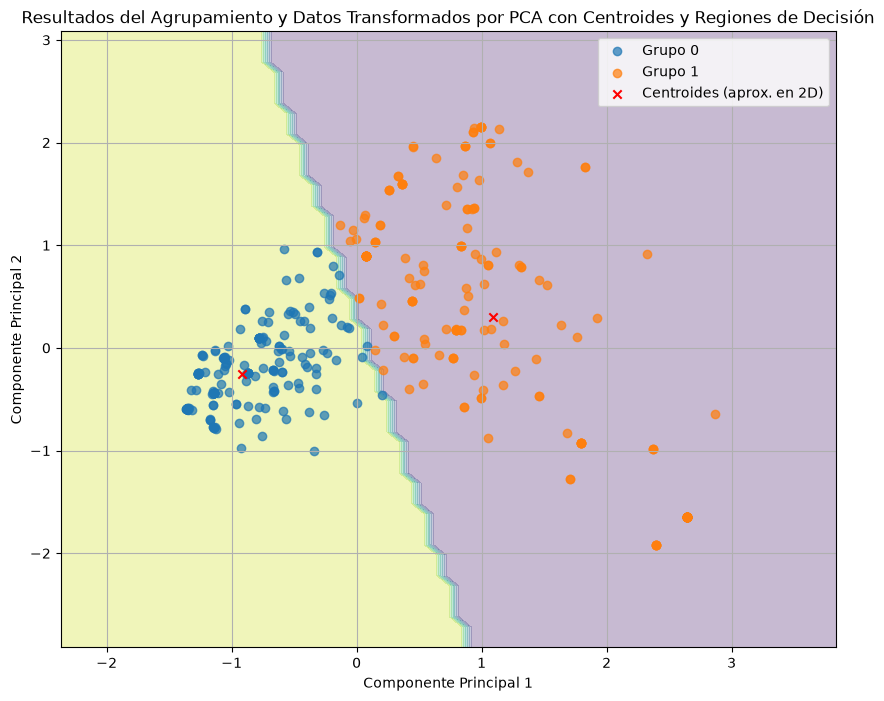

In [21]:
# NOTA: las regiones de fondo de este gráfico se calculan ajustando un NUEVO
# KMeans directamente sobre los datos ya reducidos a 2D (X_2d) — es una
# aproximación hecha solo para poder dibujar una "región de decisión" en 2D,
# distinta del agrupamiento original (hecho sobre las 330 dimensiones y ya
# alineado con las clases reales, que es el que determina el COLOR de cada
# punto). Por eso es posible ver algún punto cuyo color no combina
# perfectamente con la región de fondo en la que cae: son dos particiones
# relacionadas pero no idénticas.

# Crear una instancia de KMeans con el número óptimo de grupos, ajustada
# únicamente sobre los datos en 2D (solo para fines de visualización)
kmeans_2d = KMeans(n_clusters=optimal_k, random_state=42)
kmeans_2d.fit(X_2d)

# Obtener los centroides en el espacio de dos dimensiones
centroides_2d = kmeans_2d.cluster_centers_

# Obtener los límites de los datos transformados por PCA
x_min, x_max = df_resultado['Componente Principal 1'].min() - 1, df_resultado['Componente Principal 1'].max() + 1
y_min, y_max = df_resultado['Componente Principal 2'].min() - 1, df_resultado['Componente Principal 2'].max() + 1

# Crear una cuadrícula de puntos para representar la región de cada grupo
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.1), np.arange(y_min, y_max, 0.1))

# Predecir el grupo para cada punto en la cuadrícula
Z = kmeans_2d.predict(np.c_[xx.ravel(), yy.ravel()])

# Convertir los resultados de la predicción a la forma de la cuadrícula
Z = Z.reshape(xx.shape)

# Crear una figura
plt.figure(figsize=(10, 8))

# Graficar las regiones de decisión (aproximadas, ver nota arriba)
plt.contourf(xx, yy, Z, alpha=0.3)

# Graficar cada muestra con un color correspondiente al grupo al que pertenece
# según el agrupamiento ORIGINAL (330 dimensiones, ya alineado con las clases reales)
for cluster in range(optimal_k):
    plt.scatter(df_resultado[df_resultado['Grupo'] == cluster]['Componente Principal 1'],
                df_resultado[df_resultado['Grupo'] == cluster]['Componente Principal 2'],
                label=f'Grupo {cluster}', alpha=0.7)

# Graficar los centroides de cada grupo (del KMeans ajustado en 2D)
plt.scatter(centroides_2d[:, 0], centroides_2d[:, 1], marker='x', color='red', label='Centroides (aprox. en 2D)')

# Añadir etiquetas y leyenda
plt.title('Resultados del Agrupamiento y Datos Transformados por PCA con Centroides y Regiones de Decisión')
plt.xlabel('Componente Principal 1')
plt.ylabel('Componente Principal 2')
plt.legend()
plt.grid(True)

# Mostrar el gráfico
plt.show()

A pesar de que la representación gráfica de los datos ayuda a entender mejor el problema, se necesita evaluar la calidad del agrupamiento.

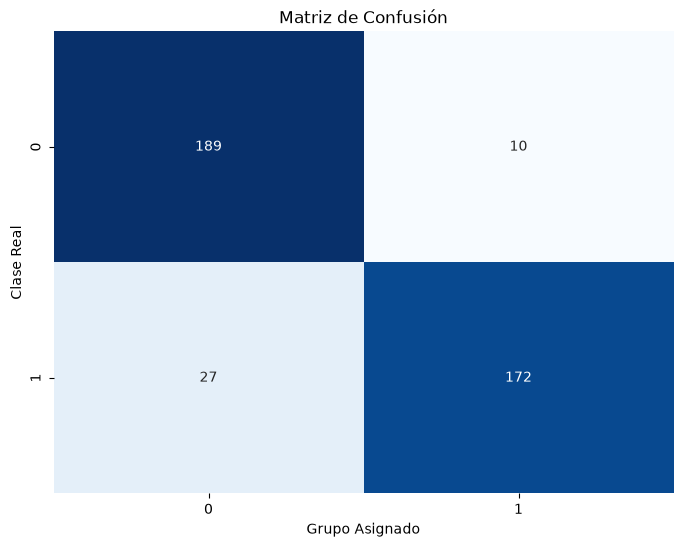

Matriz de Confusión:
[[189  10]
 [ 27 172]]

Reporte de Clasificación:
              precision    recall  f1-score   support

           0       0.88      0.95      0.91       199
           1       0.95      0.86      0.90       199

    accuracy                           0.91       398
   macro avg       0.91      0.91      0.91       398
weighted avg       0.91      0.91      0.91       398



In [22]:
# Obtener las etiquetas reales de las clases y los grupos
etiquetas_reales_clase = apks_df['type']
etiquetas_reales_grupo = apks_df['clusters']

# Crear la matriz de confusión
matriz_confusion = confusion_matrix(etiquetas_reales_clase, etiquetas_reales_grupo)

# Crear un heatmap de la matriz de confusión
plt.figure(figsize=(8, 6))
sns.heatmap(matriz_confusion, annot=True, cmap='Blues', fmt='g', cbar=False)

# Añadir etiquetas y título
plt.title('Matriz de Confusión')
plt.xlabel('Grupo Asignado')
plt.ylabel('Clase Real')

# Mostrar el heatmap
plt.show()

# Imprimir la matriz de confusión
print("Matriz de Confusión:")
print(matriz_confusion)

# Obtener el reporte de clasificación
reporte = classification_report(etiquetas_reales_clase, etiquetas_reales_grupo)

# Imprimir el reporte de clasificación
print("\nReporte de Clasificación:")
print(reporte)


Del análisis de agrupamiento anterior se obtuvo (una vez alineadas las etiquetas de los clusters con la clase real mayoritaria):

1. **Matriz de Confusión**:
   - Fila 1 (clase real *benigno*): 189 APKs benignas quedaron en el cluster "benigno" (verdaderos negativos), y solo 10 en el cluster "maligno" (falsos positivos).
   - Fila 2 (clase real *maligno*): 172 APKs maliciosas quedaron en el cluster "maligno" (verdaderos positivos), y 27 en el cluster "benigno" (falsos negativos).

2. **Reporte de Clasificación**: precisión y recall alrededor de 0.86-0.95 para ambas clases, con una exactitud (*accuracy*) global de **91%**.

Estos resultados son sorprendentemente buenos para un método **no supervisado**: sin usar jamás la etiqueta real durante el entrenamiento, KMeans logró separar benignas de malignas usando únicamente los patrones de permisos solicitados, en un 91% de los casos. Esto confirma que existe una estructura real y bien diferenciada en los datos entre APKs benignas y maliciosas — la misma estructura que el análisis de "permisos más discriminantes" (más arriba) ya había insinuado, y que el modelo de clasificación supervisada (más adelante) va a aprovechar de forma mucho más precisa al sí tener acceso a las etiquetas reales durante el entrenamiento.

Una vez obtenidos los grupos, estos deben analizarse para identificar los patrones ocultos.

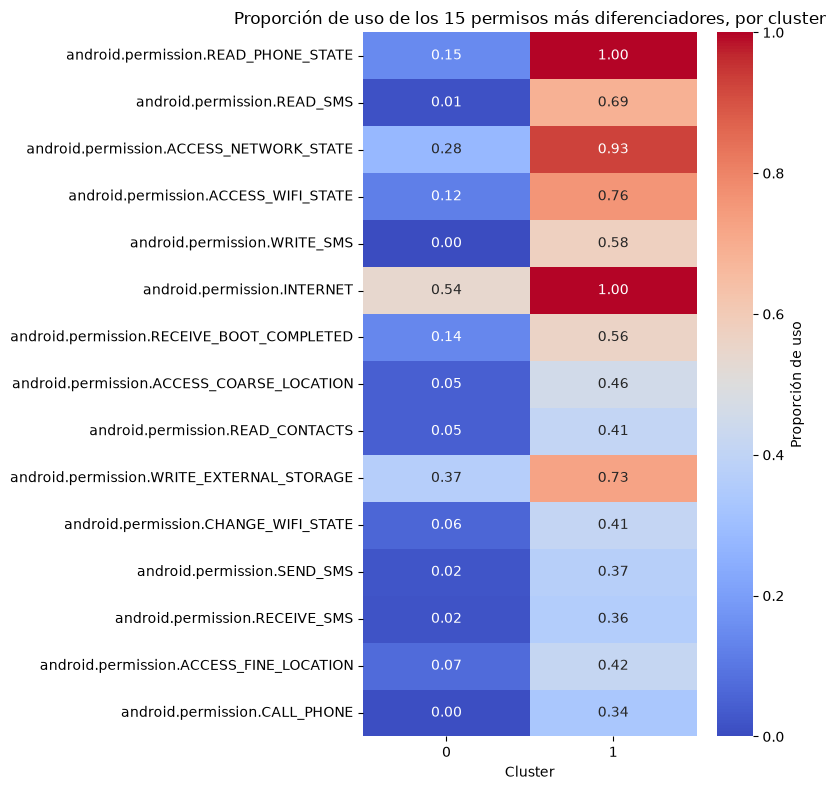

In [23]:
# Para que la visualización sea legible, nos quedamos solo con las columnas de
# permisos (excluyendo "total_permisos", que está en una escala de conteo, no de
# proporción 0-1, y mezclarla distorsionaría la comparación) y, de esas ~329
# columnas, solo con los 15 permisos que más difieren entre ambos clusters —
# graficar las 329 columnas completas sería ilegible.
permisos_num = [c for c in apks_df.select_dtypes(include=[np.number]).columns
                if c not in ('type', 'total_permisos', 'clusters')]
group_stats = apks_df.groupby('clusters')[permisos_num].mean()

diferencia_grupos = (group_stats.loc[1] - group_stats.loc[0]).abs().sort_values(ascending=False)
top_permisos_grupo = diferencia_grupos.head(15).index.tolist()

plt.figure(figsize=(8, 8))
sns.heatmap(group_stats[top_permisos_grupo].T, cmap='coolwarm', annot=True, fmt='.2f', cbar_kws={'label': 'Proporción de uso'})
plt.title('Proporción de uso de los 15 permisos más diferenciadores, por cluster')
plt.xlabel('Cluster')
plt.tight_layout()
plt.show()

In [24]:
# En vez de imprimir una tabla enorme con una fila por cada estadística de cada
# una de las 329 columnas de permisos (poco legible), se muestra un resumen
# acotado: el promedio de permisos totales por cluster, y los 5 permisos más
# frecuentes dentro de cada uno — suficiente para caracterizar a cada grupo.
print('Promedio de total_permisos por cluster:')
print(apks_df.groupby('clusters')['total_permisos'].mean())
print()

permisos_cluster = [c for c in apks_df.columns if c not in ('type', 'class', 'total_permisos', 'clusters')]
for cluster_id in sorted(apks_df['clusters'].unique()):
    top5_cluster = apks_df[apks_df['clusters'] == cluster_id][permisos_cluster].mean().sort_values(ascending=False).head(5)
    print(f'Top 5 permisos más frecuentes en el cluster {cluster_id}:')
    print(top5_cluster)
    print()

Promedio de total_permisos por cluster:
clusters
0     2.902778
1    13.510989
Name: total_permisos, dtype: float64

Top 5 permisos más frecuentes en el cluster 0:
android.permission.INTERNET                  0.541667
android.permission.WRITE_EXTERNAL_STORAGE    0.370370
android.permission.ACCESS_NETWORK_STATE      0.277778
android.permission.WAKE_LOCK                 0.148148
android.permission.READ_PHONE_STATE          0.148148
dtype: float64

Top 5 permisos más frecuentes en el cluster 1:
android.permission.INTERNET                  1.000000
android.permission.READ_PHONE_STATE          1.000000
android.permission.ACCESS_NETWORK_STATE      0.928571
android.permission.ACCESS_WIFI_STATE         0.758242
android.permission.WRITE_EXTERNAL_STORAGE    0.725275
dtype: float64



### Clasificación de datos

A partir de las etiquetas reales (`type` o ``class``), se debe entrenar un modelo de clasificación para aprender las APKs benignas de las malignas. Para ello se empleará un pipeline que evaluará varios clasificadores y determinará el que mejores resultados alcance de acuerdo a varias metricas, tales como precision, recall y F-Score. Para la creación del modelo se dividirá el conjunto `apks_df` en tres grupos:
- Train: se usará para aprender los patrones mediante Aprendizaje Supervisado ya que contiene las etiquetas reales. Contendrá el 70% de los datos de `apks_df` de manera aleatoria.
- Val: se usará para una primera comparación exploratoria entre los clasificadores (una sola partición). Contendrá el 10% de los datos de `apks_df` de manera aleatoria.
- Test: se dejará completamente reservado, sin usarse ni para entrenar ni para elegir el mejor clasificador, y se usará al final para simular datos desconocidos y comprobar la eficacia real del modelo elegido. Contendrá el 20% de los datos de `apks_df` de manera aleatoria.

In [25]:
# Antes de preparar los datos para el modelado, recordar el estado actual del
# DataFrame: ya incluye las columnas auxiliares creadas durante el EDA
# ('class', 'total_permisos', 'clusters'), que deberán excluirse de las
# características (X) más adelante.
apks_df

,android,android.app.cts.permission.TEST_GRANTED,android.intent.category.MASTER_CLEAR.permission.C2D_MESSAGE,android.os.cts.permission.TEST_GRANTED,android.permission.ACCESS_ALL_DOWNLOADS,android.permission.ACCESS_ALL_EXTERNAL_STORAGE,android.permission.ACCESS_BLUETOOTH_SHARE,android.permission.ACCESS_CACHE_FILESYSTEM,android.permission.ACCESS_CHECKIN_PROPERTIES,android.permission.ACCESS_COARSE_LOCATION,...,org.chromium.chrome.shell.permission.C2D_MESSAGE,org.chromium.chrome.shell.permission.DEBUG,org.chromium.chrome.shell.permission.SANDBOX,org.chromium.chromecast.shell.permission.SANDBOX,org.chromium.content_shell.permission.SANDBOX,test_permission,type,class,total_permisos,clusters
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,1,maligno,17,1
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,1,maligno,11,1
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,1,maligno,17,1
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,1,maligno,18,1
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,1,maligno,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
393,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,benigno,4,0
394,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,benigno,3,0
395,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,benigno,0,0
396,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,benigno,9,0


In [26]:
# Dividir el conjunto de datos en características (X) y etiquetas (y)
X = apks_df.drop(["type","class", "total_permisos", "clusters"], axis=1)
y = apks_df['type']

# Dividir los datos en conjunto de entrenamiento (70%) y conjunto de prueba + validación (30%).
# Se usa stratify=y para que la proporción de benignas/malignas se mantenga igual
# en cada subconjunto que en el conjunto original (que está balanceado 199/199);
# sin esto, una división aleatoria podría dejar algún subconjunto desbalanceado.
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

# Dividir el conjunto de prueba + validación en conjunto de prueba (20%) y conjunto de validación (10%)
X_test, X_val, y_test, y_val = train_test_split(X_temp, y_temp, test_size=0.333, random_state=42, stratify=y_temp)

Una vez obtenido los subconjuntos, entonces se entrenan los modelos de acuerdo con los clasificadores y las métricas predefinidos. Los clasificadores son: `SVM`, `Random Forest` y `KNN`. Puede experimentarse usando otros clasificadores.

El pipeline que se va a utilizar se define a continuación:

In [27]:
# Construir el pipeline con el preprocesamiento y el clasificador
pipeline = Pipeline([
    ('scaler', StandardScaler()),  # Escalar las características
    ('classifier', None)  # Se asigna el clasificador concreto más adelante con pipeline.set_params(...)
])

Seguidamente se define la lista de clasificadores a emplear:

In [28]:
# Definir los clasificadores que deseas incluir en el pipeline
classifiers = {
    'SVM': CalibratedClassifierCV(SVC(), ensemble=False),
    'Random Forest': RandomForestClassifier(random_state=42),
    'KNN': KNeighborsClassifier()
}

Ahora se realiza el entrenamiento de los modelos de `SVM`, `Random Forest` y `KNN`. Para ello se usarán los subconjuntos `X_train`, `y_train` (para entrenar) y `X_val`, `y_val` (para comparar los clasificadores) — el conjunto `X_test`/`y_test` se deja reservado para la evaluación final.

In [29]:
# Realizar la evaluación de modelos con validación cruzada en los conjuntos de entrenamiento y validación
results = {}
for clf_name, clf in classifiers.items():
    pipeline.set_params(classifier=clf)  # Establecer el clasificador en el pipeline
    pipeline.fit(X_train, y_train)  # Entrenar el pipeline en el conjunto de entrenamiento
    y_pred = pipeline.predict(X_val)  # Predecir etiquetas en el conjunto de validación
    precision = precision_score(y_val, y_pred)  # Calcular la precisión
    recall = recall_score(y_val, y_pred)  # Calcular el recall
    f1 = f1_score(y_val, y_pred)  # Calcular el F1-score
    auc_roc = roc_auc_score(y_val, pipeline.predict_proba(X_val)[:, 1])  # Calcular el AUC-ROC
    results[clf_name] = {
        'Precision': precision,
        'Recall': recall,
        'F-Score': f1,
        'AUC-ROC': auc_roc
    }

# Imprimir los resultados
print("Resultados de la evaluación de modelos en el conjunto de validación:")
for clf_name, scores in results.items():
    print(f"Clasificador: {clf_name}")
    print(f"Precisión: {scores['Precision']:.2f}")
    print(f"Recall: {scores['Recall']:.2f}")
    print(f"F-Score: {scores['F-Score']:.2f}")
    print(f"AUC-ROC: {scores['AUC-ROC']:.2f}")
    print("-----------------")
    print()

Resultados de la evaluación de modelos en el conjunto de validación:
Clasificador: SVM
Precisión: 0.95
Recall: 0.90
F-Score: 0.92
AUC-ROC: 0.98
-----------------

Clasificador: Random Forest
Precisión: 0.94
Recall: 0.85
F-Score: 0.89
AUC-ROC: 0.98
-----------------

Clasificador: KNN
Precisión: 1.00
Recall: 0.85
F-Score: 0.92
AUC-ROC: 0.92
-----------------



Ahora, analicemos los resultados:

- **SVM**: Tiene una precisión alta (0.95), lo que significa que tiene pocos falsos positivos. También tiene una recuperación alta (0.90), lo que indica que encuentra la mayoría de las instancias positivas. El F-Score (0.92) es alto, lo que indica un buen equilibrio entre precisión y recuperación. El AUC-ROC también es alto (0.98), lo que sugiere que el modelo puede distinguir muy bien entre las clases.

- **Random Forest**: Tiene una precisión ligeramente más baja que SVM (0.94), pero aún así es bastante alta. Su recuperación (0.85) es algo menor que la de SVM. El F-Score (0.89) es alto, aunque el más bajo de los tres. El AUC-ROC es igual de alto que el de SVM (0.98), lo que sugiere un rendimiento excepcional en la distinción entre clases.

- **KNN**: Tiene la precisión más alta de los tres (1.00, sin falsos positivos en este conjunto de validación), pero su recuperación es la más baja (0.85), lo que indica que deja pasar más instancias positivas que los otros dos. El F-Score (0.92) resulta igual de alto que el de SVM. El AUC-ROC (0.92) es el más bajo de los tres, lo que sugiere que, en general, discrimina algo peor entre clases.

Todos los clasificadores tienen un rendimiento bastante bueno en este primer vistazo. SVM y Random Forest empatan en AUC-ROC (0.98); más adelante, la validación cruzada (más robusta que esta única partición) será la que decida entre ellos.

A diferencia de la comparación anterior (que usó una sola partición de validación), ahora se evalúa cada clasificador con **validación cruzada de 10 particiones sobre el conjunto de entrenamiento** — un método más robusto porque no depende de una única división de los datos. **Será esta comparación, y no la anterior, la que determine el clasificador final.**

Además de comparar métricas, en este paso se **guarda cada modelo entrenado en un archivo** (`.joblib`) usando la librería `joblib`. Esto tiene un propósito práctico: entrenar un modelo puede tardar segundos o hasta horas dependiendo del tamaño de los datos, y no tendría sentido volver a entrenarlo cada vez que se quiera usar. Al guardarlo, se puede cargar directamente más adelante (en este mismo notebook, en otro script, o incluso en una aplicación en producción) con `joblib.load('archivo.joblib')`, listo para predecir sin re-entrenar.

In [30]:
# Definir el esquema de validación cruzada
cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

# Inicializar diccionario para almacenar los resultados y los modelos entrenados
results = {clf_name: {'precision': [], 'recall': [], 'f1': [], 'roc_auc': [], 'model': None} for clf_name in classifiers}

# Realizar la evaluación de modelos con validación cruzada en los conjuntos de entrenamiento y validación
for clf_name, clf in classifiers.items():
    print(f"Entrenando el modelo de {clf_name}...")
    pipeline.set_params(classifier=clf)  # Establecer el clasificador en el pipeline
    cv_results = cross_validate(pipeline, X_train, y_train, cv=cv, scoring=['precision', 'recall', 'f1', 'roc_auc'])
    # Almacenar los resultados de la validación cruzada
    results[clf_name]['precision'].extend(cv_results['test_precision'])
    results[clf_name]['recall'].extend(cv_results['test_recall'])
    results[clf_name]['f1'].extend(cv_results['test_f1'])
    results[clf_name]['roc_auc'].extend(cv_results['test_roc_auc'])

    # IMPORTANTE: se usa clone(pipeline) para crear una copia INDEPENDIENTE del
    # pipeline antes de entrenarla. Si en vez de esto se reutilizara el mismo
    # objeto "pipeline" en cada vuelta del ciclo, los 3 modelos guardados en
    # results[...]['model'] terminarían siendo el mismo objeto (el del último
    # clasificador entrenado), porque Python maneja los objetos por referencia.
    modelo_final = clone(pipeline)
    modelo_final.fit(X_train, y_train)
    results[clf_name]['model'] = modelo_final

    # Guardar el modelo entrenado en disco con joblib, para poder reutilizarlo
    # más adelante sin tener que volver a entrenarlo (por ejemplo, para
    # desplegarlo o para hacer una demo con nuevas APKs). Se guarda el
    # pipeline COMPLETO (StandardScaler + clasificador), no solo el
    # clasificador, para que el escalado se aplique automáticamente también
    # al predecir con datos nuevos.
    nombre_archivo = f"modelo_{clf_name.lower().replace(' ', '_')}.joblib"
    joblib.dump(modelo_final, nombre_archivo)
    print(f"  Modelo guardado en: {nombre_archivo}")

# Imprimir los resultados promedio de validación cruzada para cada clasificador
print("Resultados de la evaluación de modelos con validación cruzada:")
for clf_name, clf_results in results.items():
    print(f"Clasificador: {clf_name}")
    print("Precisión:", sum(clf_results['precision']) / len(clf_results['precision']))
    print("Recall:", sum(clf_results['recall']) / len(clf_results['recall']))
    print("F-Score:", sum(clf_results['f1']) / len(clf_results['f1']))
    print("AUC-ROC:", sum(clf_results['roc_auc']) / len(clf_results['roc_auc']))
    print("-----------------")
    print()

Entrenando el modelo de SVM...


  Modelo guardado en: modelo_svm.joblib
Entrenando el modelo de Random Forest...


  Modelo guardado en: modelo_random_forest.joblib
Entrenando el modelo de KNN...


  Modelo guardado en: modelo_knn.joblib
Resultados de la evaluación de modelos con validación cruzada:
Clasificador: SVM
Precisión: 0.9441844430079724
Recall: 0.9280219780219781
F-Score: 0.9341360060447936
AUC-ROC: 0.9653846153846155
-----------------

Clasificador: Random Forest
Precisión: 0.9154491341991342
Recall: 0.9203296703296704
F-Score: 0.9153579638752051
AUC-ROC: 0.9708006279434851
-----------------

Clasificador: KNN
Precisión: 0.9745299145299147
Recall: 0.8846153846153847
F-Score: 0.9232764856887796
AUC-ROC: 0.9499018838304553
-----------------



A continuación se muestran los resultados obtenidos mediante gráficos para mejorar su entendimiento.

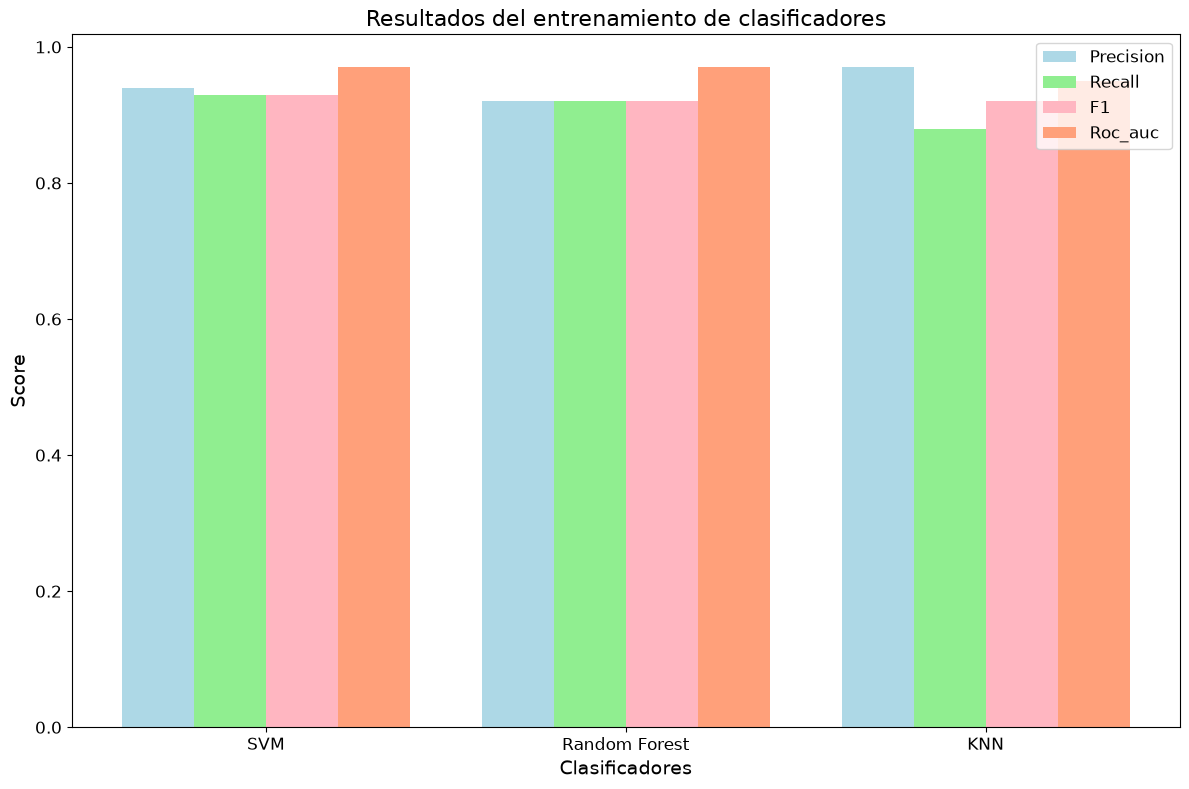

In [31]:
# Definir los nombres de los clasificadores y las métricas
classifier_names = list(results.keys())
metrics = ['precision', 'recall', 'f1', 'roc_auc']

# Inicializar una matriz para almacenar los resultados promedio de cada métrica para cada clasificador
mean_results = np.zeros((len(classifier_names), len(metrics)))

# Calcular los resultados promedio de cada métrica para cada clasificador
for i, clf_name in enumerate(classifier_names):
    for j, metric in enumerate(metrics):
        mean_results[i, j] = np.mean(results[clf_name][metric])

# Definir colores suaves para cada métrica
palette = ['lightblue', 'lightgreen', 'lightpink', 'lightsalmon']

# Crear el gráfico de barras
plt.figure(figsize=(12, 8))
bar_width = 0.2
index = np.arange(len(classifier_names)) * (len(metrics) + 1) * bar_width

for j, metric in enumerate(metrics):
    plt.bar(index + j * bar_width, np.round(mean_results[:, j], 2), bar_width, label=metric.capitalize(), color=palette[j])

# Personalizar el gráfico
plt.xlabel('Clasificadores', fontsize=14)
plt.ylabel('Score', fontsize=14)
plt.title('Resultados del entrenamiento de clasificadores', fontsize=16)
plt.xticks(index + 1.5 * bar_width, classifier_names, fontsize=12)
plt.yticks(fontsize=12)
plt.legend(fontsize=12)

# Mostrar el gráfico
plt.tight_layout()
plt.show()


El AUC-ROC (Área bajo la curva de características operativas del receptor) es una métrica de evaluación comúnmente utilizada en problemas de clasificación binaria para medir el rendimiento de un modelo de clasificación.

La curva ROC (Receiver Operating Characteristic) es una representación gráfica que muestra la relación entre la tasa de verdaderos positivos (TPR) y la tasa de falsos positivos (FPR) a medida que se varía el umbral de decisión del clasificador. El área bajo esta curva (AUC) proporciona una medida agregada del rendimiento del modelo en todas las posibles tasas de verdaderos positivos y falsos positivos.

En resumen, el AUC-ROC es una medida de la capacidad de discriminación del modelo, donde un valor más cercano a 1 indica un mejor rendimiento del modelo en términos de separación entre las clases positiva y negativa. Un valor de 0.5 indica que el modelo no tiene capacidad de discriminación (clasificación aleatoria), mientras que un valor inferior a 0.5 indica un rendimiento peor que el azar.

In [32]:
# Seleccionar la métrica
selected_metric = 'roc_auc'  # Puedes cambiar esta métrica según tus necesidades

# Calcular el promedio de la métrica seleccionada para cada clasificador
metric_mean = {clf_name: sum(clf_results[selected_metric]) / len(clf_results[selected_metric]) for clf_name, clf_results in results.items()}

# Encontrar el clasificador con el máximo promedio de la métrica seleccionada
best_classifier_name = max(metric_mean, key=metric_mean.get)
best_classifier_metrics = results[best_classifier_name]

# Imprimir el nombre del mejor clasificador y sus métricas asociadas
print(f"El mejor clasificador para la métrica '{selected_metric}' es: {best_classifier_name}")
print("Métricas del mejor clasificador:")
print(f"Precisión: {sum(best_classifier_metrics['precision']) / len(best_classifier_metrics['precision'])}")
print(f"Recall: {sum(best_classifier_metrics['recall']) / len(best_classifier_metrics['recall'])}")
print(f"F1-Score: {sum(best_classifier_metrics['f1']) / len(best_classifier_metrics['f1'])}")
print(f"AUC-ROC: {sum(best_classifier_metrics['roc_auc']) / len(best_classifier_metrics['roc_auc'])}")


El mejor clasificador para la métrica 'roc_auc' es: Random Forest
Métricas del mejor clasificador:
Precisión: 0.9154491341991342
Recall: 0.9203296703296704
F1-Score: 0.9153579638752051
AUC-ROC: 0.9708006279434851


Una vez obtenido el mejor clasificador, se evaluará con él el conjunto de prueba (`X_test`/`y_test`), que se separó al inicio y no se ha usado en ningún paso anterior (ni para entrenar, ni para seleccionar el mejor clasificador), para determinar si las muestras son benignas o malignas.

In [33]:
# Recuperar el pipeline COMPLETO (escalador + clasificador) del mejor clasificador,
# ya entrenado y guardado en el paso anterior. Es importante usar el pipeline
# completo y no el clasificador "pelón" de la lista `classifiers`: ese clasificador
# fue entrenado sobre datos ya escalados por el pipeline, así que usarlo
# directamente sobre X_test (sin escalar) daría predicciones incorrectas.
best_classifier = results[best_classifier_name]['model']

# Predecir las etiquetas para el conjunto de prueba reservado (X_test), que no se usó
# ni para entrenar ni para seleccionar el mejor clasificador
y_pred_test = best_classifier.predict(X_test)

# Convertir y_test a un DataFrame de pandas y asignar nombres de columna adecuados
y_test_df = pd.DataFrame(y_test)

# Agregar las etiquetas predichas a y_test_df en una nueva columna llamada "assigned_labels"
y_test_df['assigned_labels'] = y_pred_test

# Métricas finales sobre el conjunto de prueba
print("Evaluación final sobre el conjunto de prueba (X_test):")
print(f"Precisión: {precision_score(y_test, y_pred_test):.2f}")
print(f"Recall: {recall_score(y_test, y_pred_test):.2f}")
print(f"F-Score: {f1_score(y_test, y_pred_test):.2f}")
print(f"AUC-ROC: {roc_auc_score(y_test, best_classifier.predict_proba(X_test)[:, 1]):.2f}")

y_test_df

Evaluación final sobre el conjunto de prueba (X_test):
Precisión: 0.95
Recall: 0.97


F-Score: 0.96
AUC-ROC: 1.00


,type,assigned_labels
10,1,1
59,1,1
396,0,0
355,0,0
174,1,1
...,...,...
143,1,1
183,1,1
320,0,0
249,0,0


## Conclusiones

Retomando las preguntas de investigación y las hipótesis planteadas al inicio:

**Pregunta 1 e H1 — ¿hay permisos que por sí solos delatan al malware?**
Sí. El análisis de permisos más discriminantes mostró que `READ_PHONE_STATE` es solicitado por ~95% de las APKs maliciosas contra solo ~12% de las benignas; los permisos relacionados con SMS (`READ_SMS`, `WRITE_SMS`, `SEND_SMS`) muestran un patrón similar. **H1 se confirma.**

**Pregunta 2 e H2 — ¿se pueden separar las clases sin usar las etiquetas?**
Sí. El agrupamiento con KMeans, sin usar jamás la etiqueta real durante el entrenamiento, logró separar correctamente el 91% de las APKs. **H2 se confirma** — la señal en los datos es lo suficientemente fuerte como para emerger incluso de forma no supervisada.

**Pregunta 3 e H3 — ¿qué tan bien generaliza el modelo supervisado?**
Sí, y mejor de lo esperado. En la comparación inicial sobre el conjunto de validación, SVM y Random Forest empataron en AUC-ROC (0.98); al decidir con el método más robusto —validación cruzada de 10 particiones sobre el conjunto de entrenamiento— **Random Forest** resultó ganador (AUC-ROC 0.97). Al evaluar ese modelo sobre el conjunto de prueba —nunca antes visto—, el resultado fue: Precisión 0.95, Recall 0.97, F-Score 0.96 y AUC-ROC 1.00. **H3 se confirma**: el modelo generaliza muy bien a datos nuevos, con un desempeño en prueba consistente con (e incluso ligeramente mejor que) el observado en validación — aunque, con un dataset de solo 398 muestras, los conjuntos de validación y prueba siguen siendo pequeños (40 y 80 muestras respectivamente), y conviene no sobre-interpretar diferencias de una o dos muestras entre ambos.

**Lectura práctica para la detección de malware:**
Un Recall de 0.97 con Precisión de 0.95 significa que el modelo detecta casi todo el malware real, con muy pocos falsos positivos sobre apps benignas. Es un balance saludable para un sistema de este tipo: en producción normalmente se preferiría inclinar la balanza aún más hacia el recall (aceptando algunos falsos positivos adicionales) si el costo de dejar pasar malware es mayor que el de revisar alguna app benigna de más — algo que se puede ajustar cambiando el umbral de decisión del modelo (por defecto 0.5) en vez de usar `predict()` directamente.

**Cierre:**
Este ejercicio integró todo lo visto en el diplomado: manejo de datos con pandas (Sesión 2), un análisis exploratorio completo con detección de valores atípicos (Sesión 3), múltiples tipos de visualización — desde histogramas y boxplots hasta diagramas de radar (Sesión 4) —, y cerró introduciendo dos técnicas nuevas para el curso, agrupamiento y clasificación (incluyendo la reducción de dimensionalidad con PCA para poder visualizar los grupos), como paso natural después de un buen análisis exploratorio de datos.